# Single-system synthetic image

Linear, single-process port of `mejiro/pipeline/_04_create_synthetic_images.py` for one lens pickle. Set `sca`, `band`, and `config_path` below.

In [13]:
sca = 11
band = 'F106'
config_path = '/grad/bwedig/mejiro/projects/roman_data_challenge/roman_data_challenge_rung_1_unlabeled.yaml'

# Optional: pick a specific lens pickle. If None, the first lens found in the SCA directory is used.
input_pickle = '/data/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/03/sca11/lens_roman_data_challenge_rung_1_unlabeled_00059562.pkl'
output_pickle = '/data/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/04/sca11/SyntheticImage_roman_data_challenge_rung_1_unlabeled_00059562_F106.pkl'

In [14]:
import os
from glob import glob

import yaml

from mejiro.instruments.roman import Roman
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import roman_util, util

In [15]:
with open(config_path, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

synthetic_image_config = config['synthetic_image']
psf_config = config['psf']

data_dir = config['data_dir']
pipeline_label = config['pipeline_label']
if config.get('dev'):
    pipeline_label += '_dev'
pipeline_dir = os.path.join(data_dir, pipeline_label)

# resolve psf_cache_dir the same way PipelineHelper does
import mejiro
psf_cache_dir = config['psf_cache_dir']
if psf_cache_dir is None:
    psf_cache_dir = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'psfs', 'roman')
elif not os.path.isabs(psf_cache_dir):
    candidate = os.path.join(data_dir, psf_cache_dir)
    if not os.path.isdir(candidate):
        pkg_candidate = os.path.abspath(os.path.join(os.path.dirname(mejiro.__file__), '..', psf_cache_dir))
        if os.path.isdir(pkg_candidate):
            candidate = pkg_candidate
    psf_cache_dir = candidate

pipeline_dir, psf_cache_dir

('/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled',
 '/nfsdata1/bwedig/mejiro/cached_psfs')

In [16]:
sca_string = roman_util.get_sca_string(sca).lower()
input_dir = os.path.join(pipeline_dir, '03', sca_string)

if input_pickle is None:
    matches = sorted(glob(os.path.join(input_dir, f'lens_{pipeline_label}_*.pkl')))
    assert matches, f'No lens pickles found in {input_dir}'
    input_pickle = matches[0]

lens = util.unpickle(input_pickle)
input_pickle, lens.name

('/data/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/03/sca11/lens_roman_data_challenge_rung_1_unlabeled_00059562.pkl',
 'roman_data_challenge_rung_1_unlabeled_00059562')

In [17]:
instrument = Roman()

num_pix = psf_config['num_pixes'][0]
divide_up_detector = psf_config.get('divide_up_detector')
supersampling_factor = synthetic_image_config['supersampling_factor']

# pick the central detector position deterministically (no randomness for a single-system run)
possible_positions = roman_util.divide_up_sca(divide_up_detector)
detector_position = possible_positions[len(possible_positions) // 2]

instrument_params = {'detector': sca, 'detector_position': detector_position}

kwargs_psf = instrument.get_psf_kwargs(
    band=band,
    detector=sca,
    detector_position=detector_position,
    oversample=supersampling_factor,
    num_pix=num_pix,
    check_cache=True,
    psf_cache_dir=psf_cache_dir,
    require_cached=True,
)

In [18]:
kwargs_numerics = {
    'supersampling_factor': supersampling_factor,
    'compute_mode': synthetic_image_config['supersampling_compute_mode'],
}

synthetic_image = SyntheticImage(
    strong_lens=lens,
    instrument=instrument,
    band=band,
    fov_arcsec=synthetic_image_config['fov_arcsec'],
    instrument_params=instrument_params,
    kwargs_numerics=kwargs_numerics,
    kwargs_psf=kwargs_psf,
    pieces=synthetic_image_config['pieces'],
)
synthetic_image

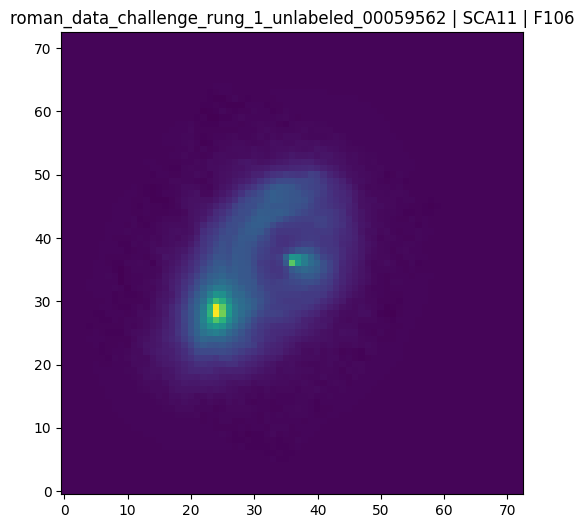

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(synthetic_image.data, origin='lower')
ax.set_title(f'{lens.name} | SCA{sca:02d} | {band}')
plt.savefig('figures/single_synthetic_image/synthetic_image.png', dpi=300)
plt.show()

In [20]:
util.pickle(output_pickle, synthetic_image)